In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Analyses of price and return dynamics between South Korean KOSPI equity index and the South Korean equity tracking ETF EWY

*Since April 2025, with the onset of President Donald Trump's Liberation Day tariffs, institutional interest in diversifying the geographical concentration of holdings has increased, leading to large inflows into leading equities of emerging markets.*

*South Korea has been one of the standouts of this Anywhere-But-The-USA trade. With South Korea's stock market being dominated heavily by memory semiconductor companies, such as Samsung Electronics and SK hynix, the inflow of funds was driven by a two-pronged investment narrative: Investors who wanted to invest in strong companies outside of the USA, and investors who wanted a slice of the AI pie allocated to memory semiconductors.*

*With this in mind, and my interest in all things South Korean, I have been closely watching the South Korean market. After the 삼일절 market holiday in South Korea on 2nd Mar 2026, from day to day, I noticed that the correlation between the KOSPI index and EWY ETF seemed to have been decoupled. Eventually (i.e. now) I have decided to formalise this by looking into their relationship, and potentially devise a trading strategy to compete with the KOSPI's miracle run.*

### Functions

In [819]:
def setup_returns(df):
    """
    Sets up daily returns and respective cumulative return columns in a dataframe
    """
    df['Returns'] = df['Adj Close'].pct_change().values
    df['Cumulative Returns'] = (1 + df['Returns'].fillna(0)).cumprod()
    return df

def setup_weekly_returns(df):
    """
    Sets up weekly returns and respective cumulative return columns in a dataframe
    """
    df.index = pd.to_datetime(df.index)
    
    weekly_df = df.resample('W').last()
    weekly_df['Returns'] = weekly_df['Adj Close'].pct_change()
    weekly_df['Cumulative Returns'] = (1 + weekly_df['Returns'].fillna(0)).cumprod()
    return weekly_df[['Adj Close', 'Returns', 'Cumulative Returns']]

In [ ]:
def calc_max_dd(series):
    max_dd = 0.0
    s = series.values
    cumu_max = 1 + s[0]
    curr_cumu = 1 + s[0]
    for r in s[1:]:
        curr_cumu = (1 + r) * curr_cumu
        cumu_max = max(curr_cumu, cumu_max)
        max_dd = min(max_dd, (curr_cumu - cumu_max) / cumu_max)
    return max_dd

def calc_sharpe(series):
    return series.mean() / series.std() * np.sqrt(252)

def calculate_sortino_ratio(returns, rf=0, target_return=0):
    """
    returns: Series of daily strategy returns
    rf: Annualized risk-free rate (e.g., 0.02 for 2%)
    target_return: The 'Minimum Acceptable Return' (usually 0)
    """
    # Annualization factor for daily data
    ann_factor = 252
    daily_rf = rf / ann_factor
    
    # Calculate excess returns
    excess_returns = returns - daily_rf
    
    # Calculate downside deviation
    # We only care about returns that fall below our target_return
    downside_diff = returns - target_return
    downside_diff = downside_diff[downside_diff < 0]
    downside_deviation = np.sqrt(np.mean(downside_diff**2)) * np.sqrt(ann_factor)
    
    # Calculate annualized mean return
    annualized_return = excess_returns.mean() * ann_factor
    
    # Handle division by zero
    if downside_deviation == 0:
        return np.nan
        
    return annualized_return / downside_deviation

### Daily data

#### Full period analyses

In [199]:
start_date = dt.date(2025,5,11)
end_date = dt.date(2026,5,10)
EWY_data = yf.download("EWY", start_date, end_date, auto_adjust = False)
KOSPI_data = yf.download("^KS11", start_date, end_date, auto_adjust = False)
KRW_data = yf.download("KRW=X", start_date, end_date, auto_adjust = False)
SMH_data = yf.download("SMH", start_date, end_date, auto_adjust = False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [203]:
EWY_data = EWY_data[['Adj Close', 'Volume']].copy()
KOSPI_data = KOSPI_data[['Adj Close', 'Volume']].copy()
SMH_data = SMH_data[['Adj Close', 'Volume']].copy()
KRW_data = KRW_data[['Adj Close', 'Volume']].copy()

EWY_data = setup_returns(EWY_data)
KOSPI_data = setup_returns(KOSPI_data)
KRW_data = setup_returns(KRW_data)
SMH_data = setup_returns(SMH_data)

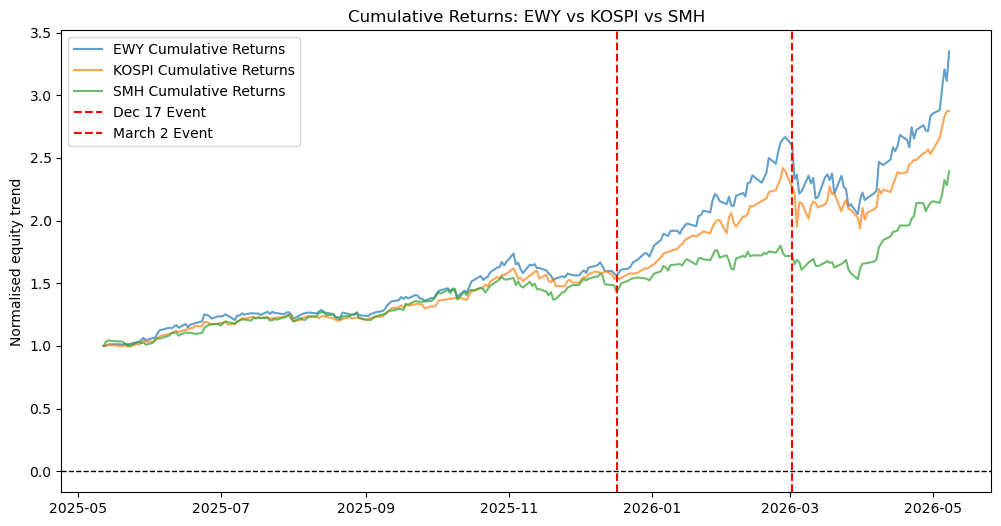

In [205]:
plt.figure(figsize=(12, 6))
plt.plot(EWY_data.index, EWY_data['Cumulative Returns'], label='EWY Cumulative Returns', alpha=0.7)
plt.plot(KOSPI_data.index, KOSPI_data['Cumulative Returns'], label='KOSPI Cumulative Returns', alpha=0.7)
plt.plot(SMH_data.index, SMH_data['Cumulative Returns'], label='SMH Cumulative Returns', alpha=0.7)

# Price trend started diverging after this date
plt.axvline(x=pd.to_datetime('2025-12-17'), color='red', linestyle='--', lw=1.5, label='Dec 17 Event')

# South Korea Samiljeol independence day holiday
plt.axvline(x=pd.to_datetime('2026-03-02'), color='red', linestyle='--', lw=1.5, label='March 2 Event')

plt.axhline(0, color='black', lw=1, ls='--') # Add a horizontal line at 0
plt.title('Cumulative Returns: EWY vs KOSPI vs SMH')
plt.ylabel('Normalised equity trend')
plt.legend()
plt.show()

Correlation (R): 0.2157
R-squared: 0.0465
Beta (Slope): 0.2373
Alpha (Intercept): 0.0043


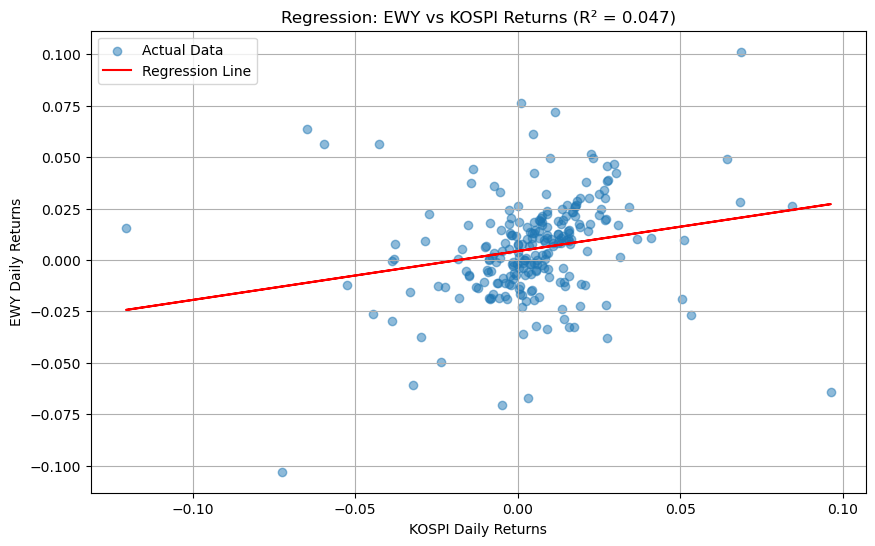

In [207]:
### Without KRW
import scipy.stats as stats

# Align data and remove the first row (NaN from pct_change)
combined_df = pd.concat([KOSPI_data['Returns'], EWY_data['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY']

slope, intercept, r_value, p_value, std_err = stats.linregress(combined_df['KOSPI'], combined_df['EWY'])

r_squared = r_value**2

print(f"Correlation (R): {r_value:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Beta (Slope): {slope:.4f}")
print(f"Alpha (Intercept): {intercept:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['KOSPI'], combined_df['EWY'], alpha=0.5, label='Actual Data')
plt.plot(combined_df['KOSPI'], intercept + slope * combined_df['KOSPI'], color='red', label='Regression Line')

plt.title(f'Regression: EWY vs KOSPI Returns (R² = {r_squared:.3f})')
plt.xlabel('KOSPI Daily Returns')
plt.ylabel('EWY Daily Returns')
plt.legend()
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     21.93
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.89e-09
Time:                        19:55:33   Log-Likelihood:                 558.09
No. Observations:                 235   AIC:                            -1110.
Df Residuals:                     232   BIC:                            -1100.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0034      0.002      2.225      0.0

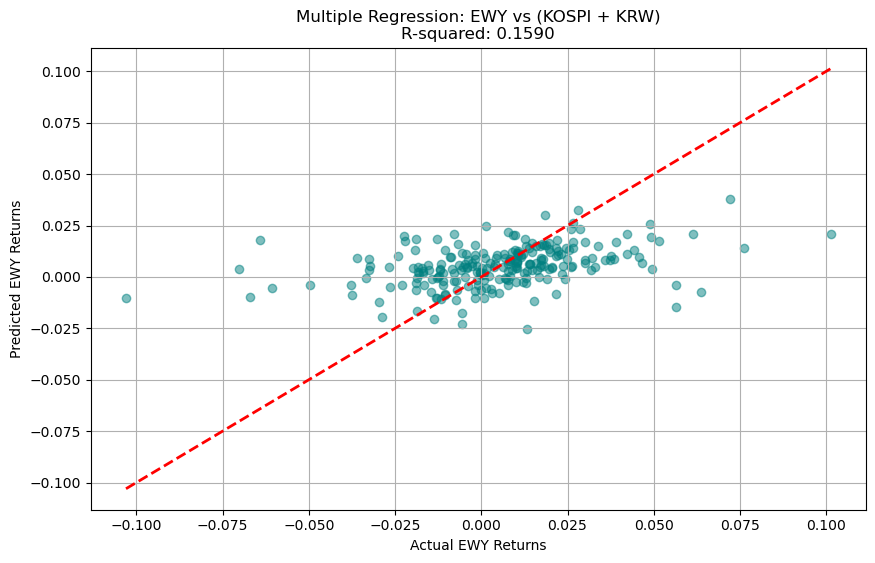

In [209]:
### Adding KRW to the regression

combined_df = pd.concat([KOSPI_data['Returns'], EWY_data['Returns'], KRW_data['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

# Statsmodels doesn't include an intercept by default
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights from data analyses of daily returns from full series**

- Poor overall R-sq of 0.05
- Adding effect of FX as a predictor improves R-sq to 0.16 (see if FX fluctuations can help explain some of the variation in EWY that is not explained by KOSPI returns)
- At a glance, there appears to be low correlation between daily returns of EWY and KOSPI in the overall time series. The next step is to split the time series by several potentially key dates to see if any stronger correlation can be detected.

#### Date 1: Divergence

In [213]:
split_date = dt.date(2025,12,17)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     35.50
Date:                Mon, 11 May 2026   Prob (F-statistic):           3.38e-13
Time:                        19:58:32   Log-Likelihood:                 412.59
No. Observations:                 143   AIC:                            -819.2
Df Residuals:                     140   BIC:                            -810.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.001      0.821      0.4

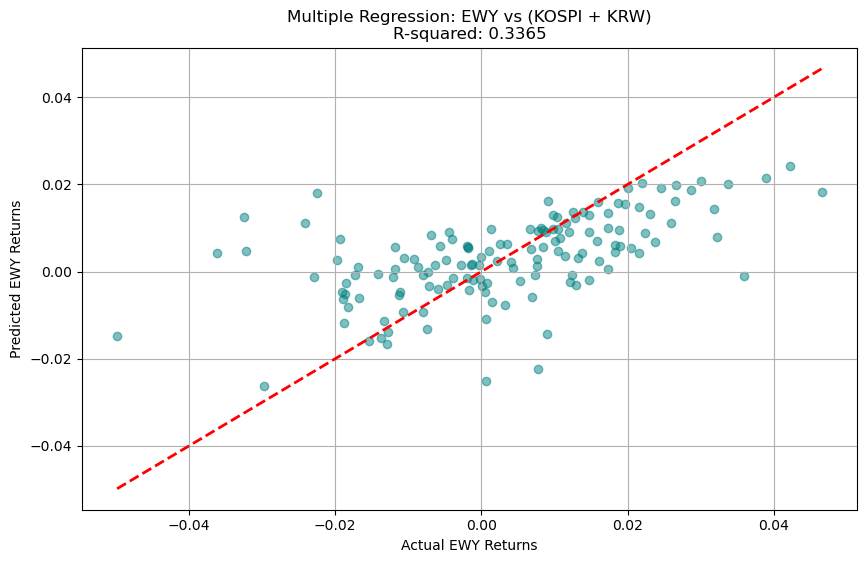

In [215]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     8.814
Date:                Mon, 11 May 2026   Prob (F-statistic):           0.000324
Time:                        19:58:48   Log-Likelihood:                 189.05
No. Observations:                  91   AIC:                            -372.1
Df Residuals:                      88   BIC:                            -364.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0066      0.003      1.979      0.0

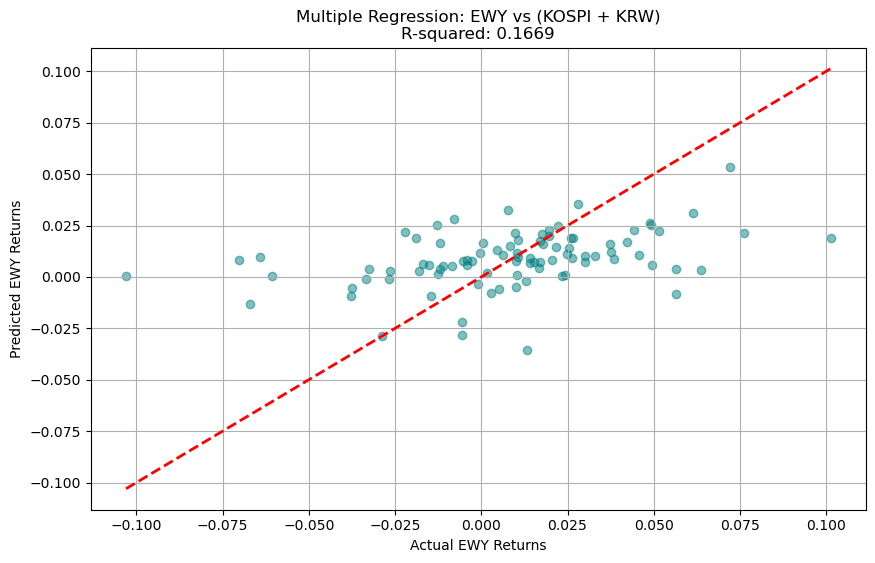

In [217]:
# 1. Align data and handle NaNs
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

# 2. Define your variables
# y is what we want to explain (EWY)
# X contains our predictors (KOSPI and KRW)
y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

# 3. Add a constant (Alpha/Intercept)
# Statsmodels doesn't include an intercept by default
X = sm.add_constant(X)

# 4. Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()

# 5. Output Results
print(model.summary())

# 6. Visualization: Actual vs. Predicted
# (Since we have 2 predictors, we can't do a simple 2D line plot easily. 
# A common way to show fit is 'Actual vs Predicted')
combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

In [219]:
# normally, if the KRW is decreasing (i.e. KRW=X is rallying), EWY holdings are worth fewer KRW, so EWY should decrease. The beta
# should thus be negative but it is positive
# therefore sanity check the fact that KRW=X is rallying together with EWY
print(combined_df[['EWY', 'KOSPI', 'KRW']].corr())

            EWY     KOSPI       KRW
EWY    1.000000  0.097345  0.291788
KOSPI  0.097345  1.000000 -0.509532
KRW    0.291788 -0.509532  1.000000


**Insights**

- R-sq between daily returns of EWY regressed on KOSPI and KRW before key date is low at 0.34, but higher than full period of 0.16
- R-sq after the key date is much lower at 0.17

#### Date 2: South Korea Market Holiday

In [222]:
split_date = dt.date(2026,3,2)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     35.16
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.12e-13
Time:                        20:02:21   Log-Likelihood:                 522.90
No. Observations:                 189   AIC:                            -1040.
Df Residuals:                     186   BIC:                            -1030.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.001      2.194      0.0

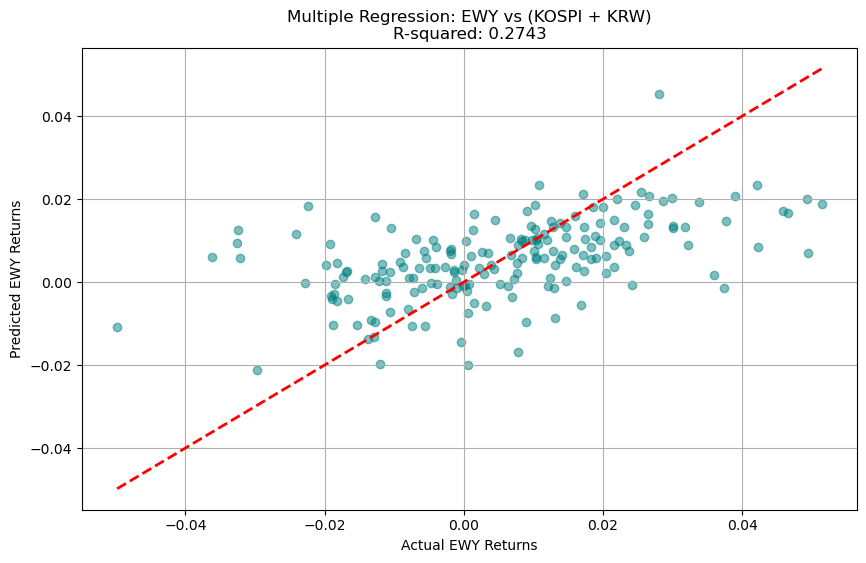

In [224]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     7.383
Date:                Mon, 11 May 2026   Prob (F-statistic):            0.00179
Time:                        20:02:27   Log-Likelihood:                 88.613
No. Observations:                  45   AIC:                            -171.2
Df Residuals:                      42   BIC:                            -165.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.005      0.979      0.3

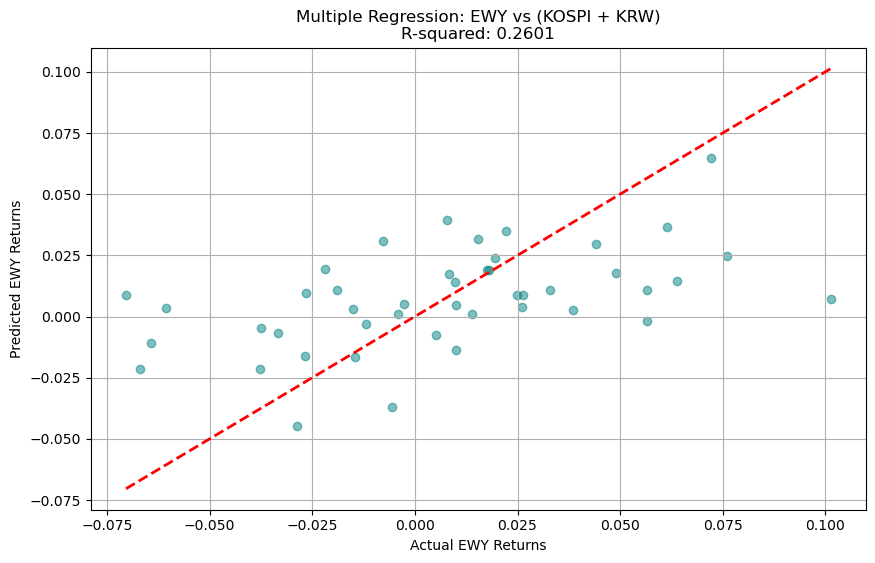

In [226]:
# 1. Align data and handle NaNs
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

# 2. Define your variables
# y is what we want to explain (EWY)
# X contains our predictors (KOSPI and KRW)
y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

# 3. Add a constant (Alpha/Intercept)
# Statsmodels doesn't include an intercept by default
X = sm.add_constant(X)

# 4. Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()

# 5. Output Results
print(model.summary())

# 6. Visualization: Actual vs. Predicted
# (Since we have 2 predictors, we can't do a simple 2D line plot easily. 
# A common way to show fit is 'Actual vs Predicted')
combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- R-sq is now more even between both periods.
- R-sq between daily returns of EWY regressed on KOSPI and KRW before key date is still low at 0.27
- R-sq after the key date is slightly higher than previous key date analyses at 0.26

### Weekly data

#### Full period analyses

In [249]:
start_date = dt.date(2025,5,11)
end_date = dt.date(2026,5,10)
EWY_data = yf.download("EWY", start_date, end_date, auto_adjust = False)
KOSPI_data = yf.download("^KS11", start_date, end_date, auto_adjust = False)
KRW_data = yf.download("KRW=X", start_date, end_date, auto_adjust = False)
SMH_data = yf.download("SMH", start_date, end_date, auto_adjust = False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [251]:
EWY_data = EWY_data[['Adj Close', 'Volume']].copy()
KOSPI_data = KOSPI_data[['Adj Close', 'Volume']].copy()
SMH_data = SMH_data[['Adj Close', 'Volume']].copy()
KRW_data = KRW_data[['Adj Close', 'Volume']].copy()

EWY_data = setup_weekly_returns(EWY_data)
KOSPI_data = setup_weekly_returns(KOSPI_data)
KRW_data = setup_weekly_returns(KRW_data)
SMH_data = setup_weekly_returns(SMH_data)

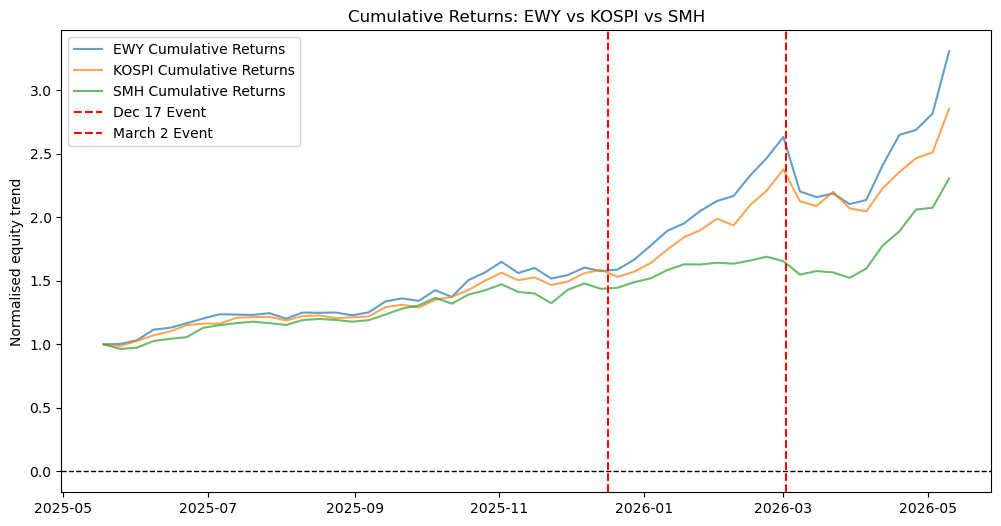

In [253]:
plt.figure(figsize=(12, 6))
plt.plot(EWY_data.index, EWY_data['Cumulative Returns'], label='EWY Cumulative Returns', alpha=0.7)
plt.plot(KOSPI_data.index, KOSPI_data['Cumulative Returns'], label='KOSPI Cumulative Returns', alpha=0.7)
plt.plot(SMH_data.index, SMH_data['Cumulative Returns'], label='SMH Cumulative Returns', alpha=0.7)

# Some divergence I dont know
plt.axvline(x=pd.to_datetime('2025-12-17'), color='red', linestyle='--', lw=1.5, label='Dec 17 Event')

# south korea independence day holiday
plt.axvline(x=pd.to_datetime('2026-03-02'), color='red', linestyle='--', lw=1.5, label='March 2 Event')

plt.axhline(0, color='black', lw=1, ls='--') # Add a horizontal line at 0
plt.title('Cumulative Returns: EWY vs KOSPI vs SMH')
plt.ylabel('Normalised equity trend')
plt.legend()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     82.43
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.99e-16
Time:                        20:07:33   Log-Likelihood:                 117.38
No. Observations:                  51   AIC:                            -228.8
Df Residuals:                      48   BIC:                            -223.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0046      0.004      1.099      0.2

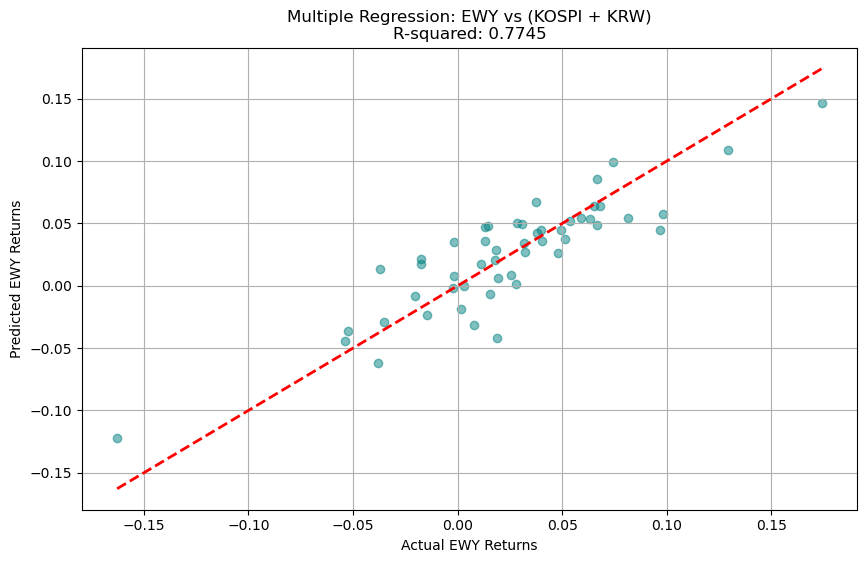

In [255]:
combined_df = pd.concat([KOSPI_data['Returns'], EWY_data['Returns'], KRW_data['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- R-sq is vastly improved, implying that the relationship between daily returns is noisy, which can be smoothed out by sampling weekly data instead.
- The R-sq of weekly returns is 0.77, which indicates a strong linear relationship between weekly returns of EWY and KOSPI.

#### Date 1: Divergence

In [257]:
split_date = dt.date(2025,12,17)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_weekly_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     26.60
Date:                Mon, 11 May 2026   Prob (F-statistic):           4.14e-07
Time:                        20:07:45   Log-Likelihood:                 73.371
No. Observations:                  30   AIC:                            -140.7
Df Residuals:                      27   BIC:                            -136.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.005      0.315      0.7

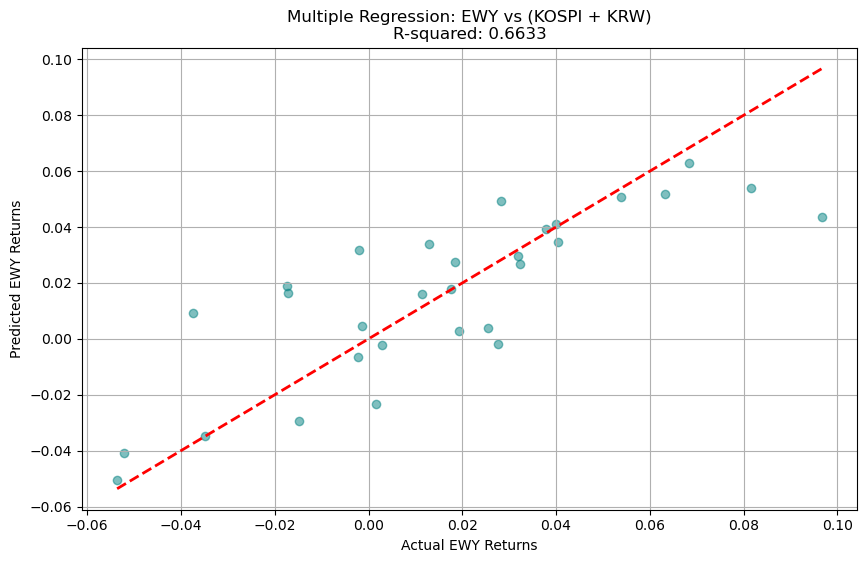

In [259]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     40.34
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.23e-07
Time:                        20:08:37   Log-Likelihood:                 45.617
No. Observations:                  21   AIC:                            -85.23
Df Residuals:                      18   BIC:                            -82.10
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0091      0.008      1.154      0.2

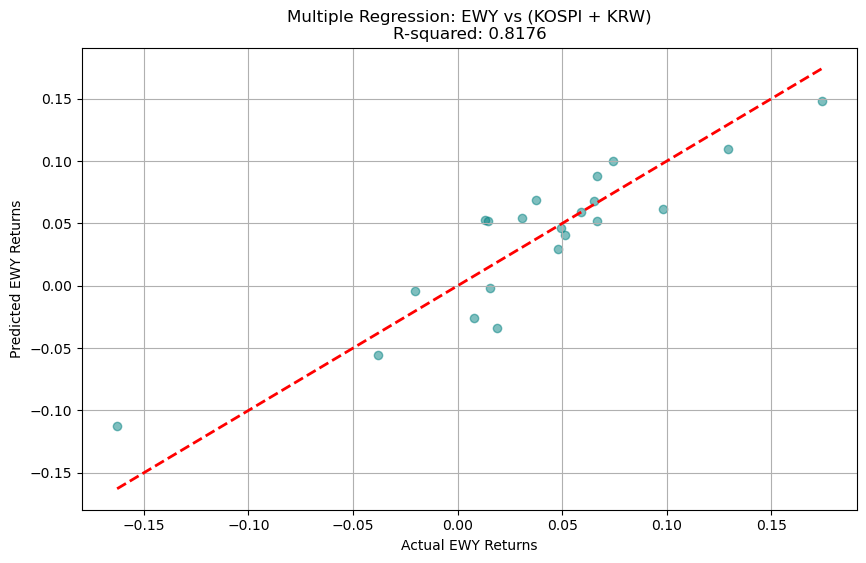

In [261]:
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- R-sq on the before set is higher than in the overall time-series (0.82 vs 0.77)
- R-sq on weekly data in the after set is much higher than that of the before set (0.82 vs 0.66)

#### Date 2: South Korea market holiday

In [269]:
split_date = dt.date(2026,3,2)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_weekly_returns(dataframe)

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     30.86
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.10e-08
Time:                        20:11:19   Log-Likelihood:                 98.283
No. Observations:                  41   AIC:                            -190.6
Df Residuals:                      38   BIC:                            -185.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0066      0.005      1.464      0.1

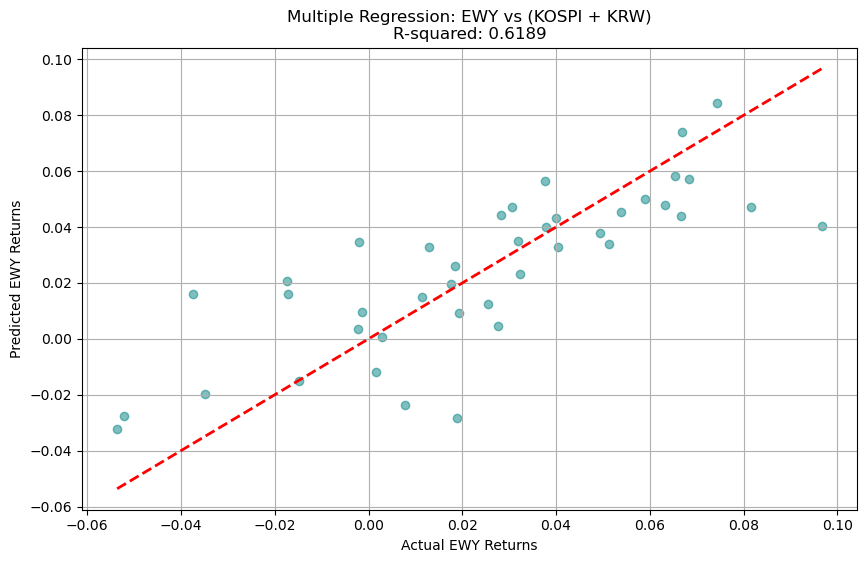

In [271]:
combined_df = pd.concat([KOSPI_before['Returns'], EWY_before['Returns'], KRW_before['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                    EWY   R-squared:                       0.927
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     44.76
Date:                Mon, 11 May 2026   Prob (F-statistic):           0.000103
Time:                        20:11:30   Log-Likelihood:                 23.039
No. Observations:                  10   AIC:                            -40.08
Df Residuals:                       7   BIC:                            -39.17
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0111      0.011      1.045      0.3

C:\Users\Raymon\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


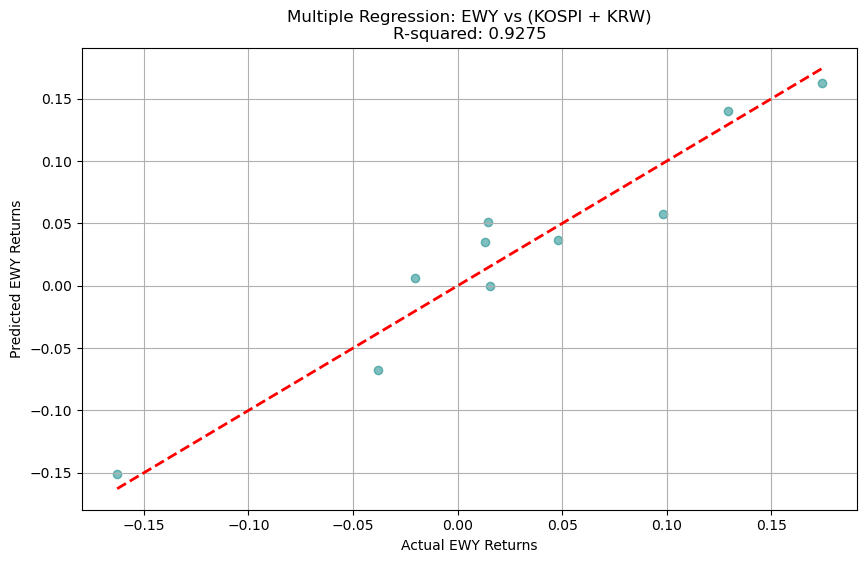

In [273]:
combined_df = pd.concat([KOSPI_after['Returns'], EWY_after['Returns'], KRW_after['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

**Insights**

- The R-sq in the second period is much higher than the R-sq in the first. But it is less reliable, as there are few datapoints to construct a representative line of best fit.

### NAV reconstruction and analysis

Reconstructing the NAV of EWY could be helpful in explaining the outperformance of EWY on the KOSPI. The thought process is that demand for ETFs can cause the ETF price to diverge above the NAV of the constituent equities.

In [54]:
EWY_ETF_stats = pd.read_excel(r'EWY data.xlsx')
EWY_units = 126150000

C:\Users\Raymon\AppData\Local\Temp\ipykernel_2356\3045322864.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_prices = yf.download(all_data_tickers, start="2025-05-11", end="2026-05-11")['Close']
[*********************100%***********************]  80 of 80 completed

--- Final Reconstructed NAV (May 2026) ---
            Reconstructed_NAV
Date                         
2026-05-04         168.257880
2026-05-05         167.765427
2026-05-06         179.095663
2026-05-07         185.811457
2026-05-08         184.821595


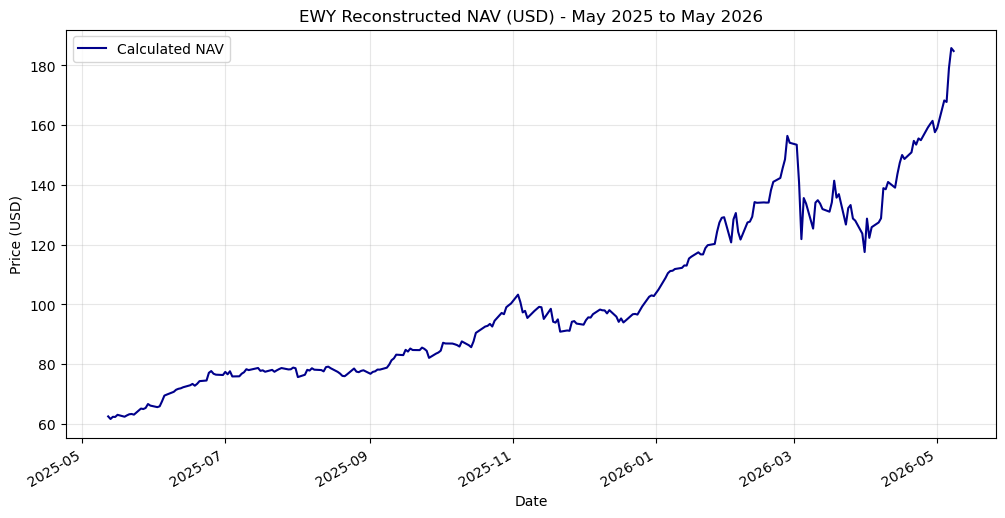

In [100]:
df_cleaned = EWY_ETF_stats.iloc[:-10].drop(index=[79, 46]).copy()

is_equity = df_cleaned['Asset Class'].str.contains('Equity', case=False, na=False)

equity_holdings = df_cleaned[is_equity].copy()
non_equity_holdings = df_cleaned[~is_equity].copy()

total_cash_krw = non_equity_holdings['Quantity'].sum()

equity_tickers = [str(t).zfill(6) + ".KS" for t in equity_holdings['Ticker']]
all_data_tickers = equity_tickers + ["USDKRW=X"]

raw_prices = yf.download(all_data_tickers, start="2025-05-11", end="2026-05-11")['Close']

raw_prices = raw_prices.ffill()

qty_map = equity_holdings.set_index(equity_holdings['Ticker'].astype(str).str.zfill(6) + ".KS")['Quantity']
daily_equity_krw = raw_prices[equity_tickers].multiply(qty_map, axis=1).sum(axis=1)

total_fund_usd = (daily_equity_krw + total_cash_krw) / raw_prices['USDKRW=X']
final_nav_df = pd.DataFrame()
final_nav_df['Reconstructed_NAV'] = total_fund_usd.dropna() / EWY_units

# Plotting Comparison
final_nav_df['Reconstructed_NAV'].plot(figsize=(12, 6), label='Calculated NAV', color='darkblue')
plt.title('EWY Reconstructed NAV (USD) - May 2025 to May 2026')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

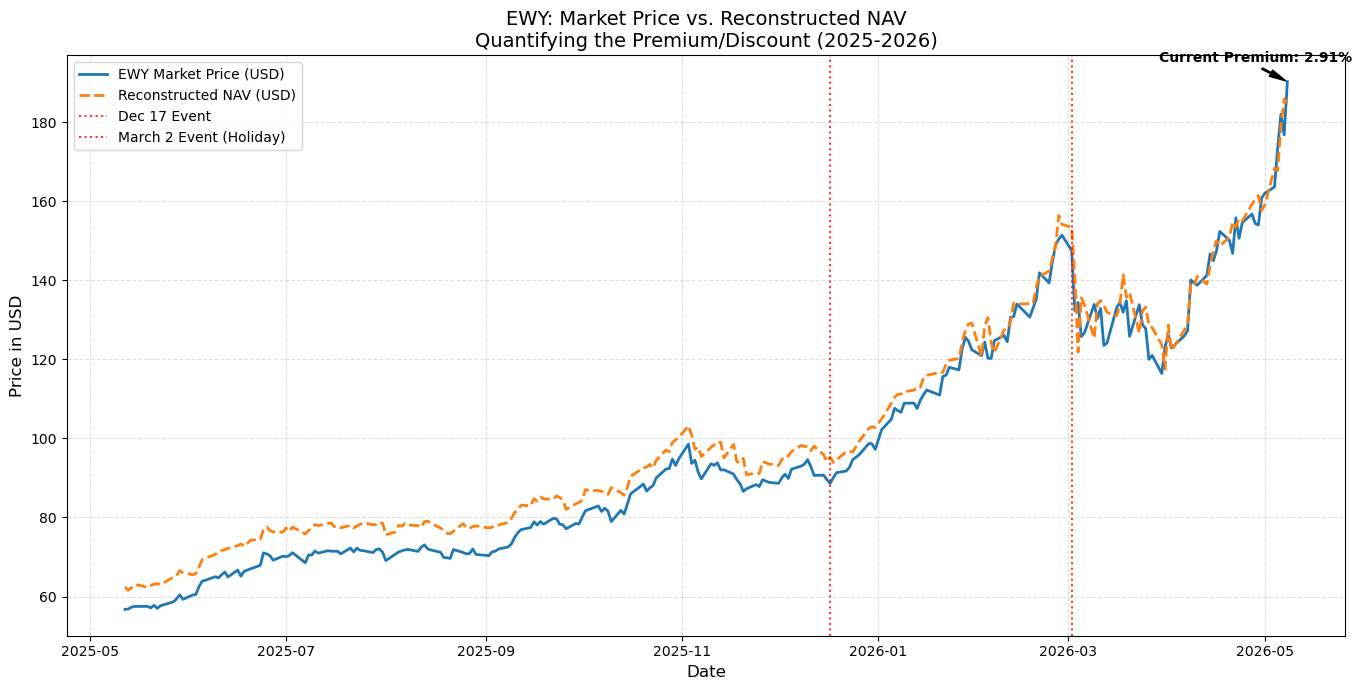

In [104]:
comparison_df = pd.concat([
    final_nav_df['Reconstructed_NAV'], 
    EWY_data['Adj Close']
], axis=1).dropna()

comparison_df.columns = ['Reconstructed_NAV', 'Market_Price']

plt.figure(figsize=(14, 7))

plt.plot(comparison_df.index, comparison_df['Market_Price'], 
         label='EWY Market Price (USD)', color='#1f77b4', linewidth=2)
plt.plot(comparison_df.index, comparison_df['Reconstructed_NAV'], 
         label='Reconstructed NAV (USD)', color='#ff7f0e', linewidth=2, linestyle='--')

plt.axvline(pd.to_datetime('2025-12-17'), color='red', linestyle=':', alpha=0.8, label='Dec 17 Event')
plt.axvline(pd.to_datetime('2026-03-02'), color='red', linestyle=':', alpha=0.8, label='March 2 Event (Holiday)')

plt.title('EWY: Market Price vs. Reconstructed NAV\nQuantifying the Premium/Discount (2025-2026)', fontsize=14)
plt.ylabel('Price in USD', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.4)

latest = comparison_df.iloc[-1]
premium = (latest['Market_Price'] - latest['Reconstructed_NAV']) / latest['Reconstructed_NAV'] * 100

plt.annotate(f'Current Premium: {premium:.2f}%', 
             xy=(comparison_df.index[-1], latest['Market_Price']),
             xytext=(comparison_df.index[-1] - pd.Timedelta(days=40), latest['Market_Price'] + 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights**

- EWY appears to have trailed its NAV early on in the period assessed. The gap reduced further into the period.
- The final premium of EWY over its constituents is 2.91%, which while significant, does not mean anything on its own, as towards the final measurement, the NAV and ETF price crossed each other multiple times, indicating that the 2.91% premium could be a momentary fluctuation.

### Results

- R-sq of weekly return data between EWY and KOSPI is much higher than daily returns.
- Daily return R-sq is low, while weekly return R-sq is much higher. I have thus devised the below trading strategy to exploit this relationship.

### Strategy

**Exploitation of high correlation in weekly returns to form a pairs trading strategy based on the spread in midweek week-to-date returns.** 

- Use the low daily correlations and high weekly correlations to define a long short strategy.
- Calculate week to date (WTD) returns for EWY and KOSPI.
- Calculate the spread between WTD returns on Wednesday as EWY_WTD_Returns - KOSPI_WTD_Returns  
- Use the spread to form a signal on Thursday and Friday.
    - If the spread > threshold: EWY is overvalued or KOSPI is undervalued. Short EWY, Long KOSPI at their respective Thursday Opens. Close at their respective Friday Closes.
    - If the spread < threshold: KOSPI is overvalued or EWY is undervalued. Short KOSPI, Long EWY at their respective Thursday Opens. Close at their respective Friday Closes.
- This strategy makes a bet on the spread to mean revert by the end of the week in terms of direction. The aim is not to beat buy-and-hold, but to minimise max drawdown and generate a higher sharpe, as trending risk-on-assets are prone to sharp corrections.

**Possible additions**:

- Stop loss: If the spread widens on Thursday, the strategy will incur losses. If the losses exceed a particular threshold, assume the spread will not close and exit the trade by EOD Thursday.
- VIX filter: Consider avoiding volatility by not trading when the VIX exceeds the long run average of 20.

In [769]:
start_date = dt.date(2025,5,11)
end_date = dt.date(2026,5,10)
EWY_data = yf.download("EWY", start_date, end_date, auto_adjust = False)
KOSPI_data = yf.download("^KS11", start_date, end_date, auto_adjust = False)
KRW_data = yf.download("KRW=X", start_date, end_date, auto_adjust = False)
VIX_data = yf.download("^VIX", start_date, end_date, auto_adjust = False)

EWY_data = setup_returns(EWY_data)
KOSPI_data = setup_returns(KOSPI_data)
KRW_data = setup_returns(KRW_data)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


#### Full period analyses

In [773]:
# Baseline long short theses
def backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold = 0.01):
    """
    EWY_data, KOSPI_data, KRW_data: DFs with 'Returns' and DatetimeIndex.
    Logic: Calculate WTD spread on Wed EOD, trade Thu/Fri.
    """
    # Align and combine data
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI': KOSPI_data['Returns'],
        'KRW': KRW_data['Returns']
    }).dropna()
    
    # Adjust KOSPI to USD terms (to match EWY)
    df['KOSPI_USD'] = (1 + df['KOSPI']) * (1 + df['KRW']) - 1
    
    # Identify Day of Week (0=Mon, 2=Wed, 3=Thu, 4=Fri)
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year

    # Calculate Week-to-Date (WTD) Returns
    # group by year/week and calculate cumulative return
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    
    # Calculate the Midweek Spread (Wednesday EOD)
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']
    
    # Generate Trade Signals
    df['Signal'] = 0
      
    # Extract Wednesday values and shift them to Thursday/Friday
    wed_signals = df[df['Day'] == 2][['Spread_WTD']]
    
    for idx, row in wed_signals.iterrows():
        # Target the following Thursday and Friday
        mask = (df['Week_ID'] == df.loc[idx, 'Week_ID']) & \
               (df['Year_ID'] == df.loc[idx, 'Year_ID']) & \
               (df['Day'] >= 3)
        
        if row['Spread_WTD'] > threshold:
            df.loc[mask, 'Signal'] = -1  # EWY too high -> Short EWY / Long KOSPI
        elif row['Spread_WTD'] < -threshold:
            df.loc[mask, 'Signal'] = 1   # EWY too low -> Long EWY / Short KOSPI

    # Calculate Strategy Returns
    df['Strategy_Ret'] = df['Signal'] * (df['EWY'] - df['KOSPI_USD'])
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()

    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

# Usage
results_df = backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, 0.01)

In [779]:
def backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold=0.01, stop_loss=-0.04):
    """
    Logic: Calculate WTD spread on Wed EOD, trade Thu/Fri.
    Stop Loss: If Thursday's return is lower than 'stop_loss', exit position for Friday.
    """
    # Align and combine data
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI': KOSPI_data['Returns'],
        'KRW': KRW_data['Returns']
    }).dropna()
    
    # Adjust KOSPI to USD terms
    df['KOSPI_USD'] = (1 + df['KOSPI']) * (1 + df['KRW']) - 1
    
    # Time Identifiers
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year

    # WTD Returns
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    
    # Calculate the Midweek Spread
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']
    
    # Generate Trade Signals with Stop Loss
    df['Signal'] = 0
    wed_signals = df[df['Day'] == 2][['Spread_WTD']]
    
    for idx, row in wed_signals.iterrows():
        week = df.loc[idx, 'Week_ID']
        year = df.loc[idx, 'Year_ID']
        
        # Define Thursday and Friday masks
        thu_mask = (df['Week_ID'] == week) & (df['Year_ID'] == year) & (df['Day'] == 3)
        fri_mask = (df['Week_ID'] == week) & (df['Year_ID'] == year) & (df['Day'] == 4)
        
        # Determine Wednesday Signal
        current_signal = 0
        if row['Spread_WTD'] > threshold:
            current_signal = -1 # Short EWY / Long KOSPI
        elif row['Spread_WTD'] < -threshold:
            current_signal = 1  # Long EWY / Short KOSPI
            
        if current_signal != 0:
            # Apply signal to Thursday
            df.loc[thu_mask, 'Signal'] = current_signal
            
            # Check Thursday performance to decide on Friday
            thu_idx = df.index[thu_mask]
            if not thu_idx.empty:
                thu_ret = current_signal * (df.loc[thu_idx, 'EWY'] - df.loc[thu_idx, 'KOSPI_USD']).iloc[0]
                
                # If Thursday didn't hit stop loss, continue to Friday
                if thu_ret > stop_loss:
                    df.loc[fri_mask, 'Signal'] = current_signal
                else:
                    # Stop loss triggered: Friday signal remains 0
                    pass

    # Calculate Strategy Returns
    df['Strategy_Ret'] = df['Signal'] * (df['EWY'] - df['KOSPI_USD'])
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()

    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

# Usage (Stop Loss set to -4%)
results_df = backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold=0.01, stop_loss=-0.04)

In [783]:
print(results_df['EWY'].std())
print(results_df['KOSPI_USD'].std())
print(results_df['Strategy_Ret'].std())

print(calc_max_dd(results_df['EWY']))
print(calc_max_dd(results_df['KOSPI_USD']))
print(calc_max_dd(results_df['Strategy_Ret']))

print(calc_sharpe(results_df['EWY']))
print(calc_sharpe(results_df['KOSPI_USD']))
print(calc_sharpe(results_df['Strategy_Ret']))


print(calculate_sortino_ratio(results_df['EWY'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['KOSPI_USD'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['Strategy_Ret'], rf=0, target_return=0))

0.024598060756911563
0.021055500500697974
0.015099138903403676
-0.2108580344084987
-0.16426724610881235
-0.09444331148076779
3.4698851736814524
3.5812105933835943
2.188340465642749
3.5748882253072156
3.3831590925594117
1.6787935453317502


#### First key date

In [785]:
split_date = dt.date(2025,12,17)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

In [717]:
results_df = backtest_midweek_convergence(EWY_before, KOSPI_before, KRW_before, 0.01)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2025-12-10,0.012347,-0.002063,-0.000395,-0.002458,2,50,2025,0.025981,0.005476,0.020505,0,0.000000,1.052780,1.674610,1.665680
2025-12-11,-0.018501,-0.005896,0.000756,-0.005144,3,50,2025,0.006999,0.000304,0.006695,-1,0.013357,1.066842,1.665995,1.634863
2025-12-12,-0.024115,0.013755,0.001232,0.015004,4,50,2025,-0.017285,0.015312,-0.032597,-1,0.039119,1.108576,1.690991,1.595438
2025-12-15,0.000647,-0.018375,0.001401,-0.017000,0,51,2025,0.000647,-0.017000,0.017647,0,0.000000,1.108576,1.662245,1.596471
2025-12-16,-0.012934,-0.022359,-0.003687,-0.025963,1,51,2025,-0.012295,-0.042521,0.030227,0,0.000000,1.108576,1.619088,1.575822


In [787]:
results_df = backtest_midweek_convergence(EWY_before, KOSPI_before, KRW_before, threshold=0.01, stop_loss=-0.04)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2025-12-10,0.012347,-0.002063,-0.000395,-0.002458,2,50,2025,0.025981,0.005476,0.020505,0,0.000000,1.093126,1.674610,1.665680
2025-12-11,-0.018501,-0.005896,0.000756,-0.005144,3,50,2025,0.006999,0.000304,0.006695,-1,0.013357,1.107727,1.665995,1.634863
2025-12-12,-0.024115,0.013755,0.001232,0.015004,4,50,2025,-0.017285,0.015312,-0.032597,-1,0.039119,1.151061,1.690991,1.595438
2025-12-15,0.000647,-0.018375,0.001401,-0.017000,0,51,2025,0.000647,-0.017000,0.017647,0,0.000000,1.151061,1.662245,1.596471
2025-12-16,-0.012934,-0.022359,-0.003687,-0.025963,1,51,2025,-0.012295,-0.042521,0.030227,0,0.000000,1.151061,1.619088,1.575822


In [789]:
print(results_df['EWY'].std())
print(results_df['KOSPI_USD'].std())
print(results_df['Strategy_Ret'].std())

print(calc_max_dd(results_df['EWY']))
print(calc_max_dd(results_df['KOSPI_USD']))
print(calc_max_dd(results_df['Strategy_Ret']))

print(calc_sharpe(results_df['EWY']))
print(calc_sharpe(results_df['KOSPI_USD']))
print(calc_sharpe(results_df['Strategy_Ret']))


print(calculate_sortino_ratio(results_df['EWY'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['KOSPI_USD'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['Strategy_Ret'], rf=0, target_return=0))

0.016646020121700498
0.014286733346317746
0.0077026909217844134
-0.12155189335863094
-0.07800493105244491
-0.029794245168558945
3.1687125839029604
3.8631342766039722
2.0885931122101864
3.3241885185861078
3.8179421048470075
1.2797863151723066


In [694]:
results_df = backtest_midweek_convergence(EWY_after, KOSPI_after, KRW_after, 0.01)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2026-04-30,0.044167,-0.013754,0.010455,-0.003443,3,18,2026,0.040046,0.024147,0.015899,1,0.047610,1.271239,1.570196,1.903559
2026-05-04,0.009815,0.051239,-0.001547,0.049613,0,19,2026,0.009815,0.049613,-0.039798,0,-0.000000,1.271239,1.648098,1.922242
2026-05-06,0.049057,0.064519,-0.001416,0.063012,2,19,2026,0.059354,0.115751,-0.056397,0,-0.000000,1.271239,1.751948,2.016542
2026-05-07,-0.028739,0.014285,-0.020021,-0.006022,3,19,2026,0.028909,0.109032,-0.080124,1,-0.022718,1.242359,1.741398,1.958588
2026-05-08,0.076096,0.001061,0.007158,0.008228,4,19,2026,0.107205,0.118157,-0.010952,0,0.000000,1.242359,1.755725,2.107629


In [791]:
results_df = backtest_midweek_convergence(EWY_after, KOSPI_after, KRW_after, threshold=0.01, stop_loss=-0.04)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2026-04-30,0.044167,-0.013754,0.010455,-0.003443,3,18,2026,0.040046,0.024147,0.015899,1,0.047610,1.322774,1.570196,1.903559
2026-05-04,0.009815,0.051239,-0.001547,0.049613,0,19,2026,0.009815,0.049613,-0.039798,0,-0.000000,1.322774,1.648098,1.922242
2026-05-06,0.049057,0.064519,-0.001416,0.063012,2,19,2026,0.059354,0.115751,-0.056397,0,-0.000000,1.322774,1.751948,2.016542
2026-05-07,-0.028739,0.014285,-0.020021,-0.006022,3,19,2026,0.028909,0.109032,-0.080124,1,-0.022718,1.292723,1.741398,1.958588
2026-05-08,0.076096,0.001061,0.007158,0.008228,4,19,2026,0.107205,0.118157,-0.010952,1,0.067869,1.380459,1.755725,2.107629


In [793]:
print(results_df['EWY'].std())
print(results_df['KOSPI_USD'].std())
print(results_df['Strategy_Ret'].std())

print(calc_max_dd(results_df['EWY']))
print(calc_max_dd(results_df['KOSPI_USD']))
print(calc_max_dd(results_df['Strategy_Ret']))

print(calc_sharpe(results_df['EWY']))
print(calc_sharpe(results_df['KOSPI_USD']))
print(calc_sharpe(results_df['Strategy_Ret']))


print(calculate_sortino_ratio(results_df['EWY'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['KOSPI_USD'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['Strategy_Ret'], rf=0, target_return=0))

0.033388231431024075
0.028684487365940932
0.022234203973911775
-0.2108580344084986
-0.1642672461088122
-0.0944433114807678
4.173929257022954
3.6599300877138314
2.700684930321862
4.104163853057845
3.3386369932229116
2.255951775084214


#### Second key date

In [795]:
split_date = dt.date(2026,3,2)

EWY_before = EWY_data[EWY_data.index < pd.Timestamp(split_date)].copy()
EWY_after = EWY_data[EWY_data.index >= pd.Timestamp(split_date)].copy()

KOSPI_before = KOSPI_data[KOSPI_data.index < pd.Timestamp(split_date)].copy()
KOSPI_after = KOSPI_data[KOSPI_data.index >= pd.Timestamp(split_date)].copy()

KRW_before = KRW_data[KRW_data.index < pd.Timestamp(split_date)].copy()
KRW_after = KRW_data[KRW_data.index >= pd.Timestamp(split_date)].copy()

for dataframe in [EWY_before, EWY_after, KOSPI_before, KOSPI_after, KRW_before, KRW_after]:
    setup_returns(dataframe)

In [705]:
results_df = backtest_midweek_convergence(EWY_before, KOSPI_before, KRW_before, 0.01)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2026-02-23,-0.018184,0.006466,-0.002977,0.003470,0,9,2026,-0.018184,0.003470,-0.021654,0,-0.0,1.216786,2.289830,2.506873
2026-02-24,0.037688,0.021134,-0.000859,0.020257,1,9,2026,0.018819,0.023797,-0.004978,0,0.0,1.216786,2.336215,2.601353
2026-02-25,0.030024,0.019133,-0.001532,0.017572,2,9,2026,0.049408,0.041787,0.007621,0,0.0,1.216786,2.377266,2.679456
2026-02-26,0.010209,0.036722,-0.009069,0.027319,3,9,2026,0.060121,0.070248,-0.010127,0,-0.0,1.216786,2.442211,2.706811
2026-02-27,0.006382,-0.010011,0.003777,-0.006271,4,9,2026,0.066887,0.063536,0.003351,0,0.0,1.216786,2.426895,2.724087


In [733]:
results_df = backtest_midweek_convergence(EWY_before, KOSPI_before, KRW_before, threshold=0.01, stop_loss=-0.04)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2026-02-23,-0.018184,0.006466,-0.002977,0.003470,0,9,2026,-0.018184,0.003470,-0.021654,0,-0.0,1.263418,2.289830,2.506873
2026-02-24,0.037688,0.021134,-0.000859,0.020257,1,9,2026,0.018819,0.023797,-0.004978,0,0.0,1.263418,2.336215,2.601353
2026-02-25,0.030024,0.019133,-0.001532,0.017572,2,9,2026,0.049408,0.041787,0.007621,0,0.0,1.263418,2.377266,2.679456
2026-02-26,0.010209,0.036722,-0.009069,0.027319,3,9,2026,0.060121,0.070248,-0.010127,0,-0.0,1.263418,2.442211,2.706811
2026-02-27,0.006382,-0.010011,0.003777,-0.006271,4,9,2026,0.066887,0.063536,0.003351,0,0.0,1.263418,2.426895,2.724087


In [797]:
results_df = backtest_midweek_convergence(EWY_after, KOSPI_after, KRW_after, 0.01)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2026-04-30,0.044167,-0.013754,0.010455,-0.003443,3,18,2026,0.040046,0.024147,0.015899,1,0.047610,1.205138,1.137944,1.214750
2026-05-04,0.009815,0.051239,-0.001547,0.049613,0,19,2026,0.009815,0.049613,-0.039798,0,-0.000000,1.205138,1.194401,1.226672
2026-05-06,0.049057,0.064519,-0.001416,0.063012,2,19,2026,0.059354,0.115751,-0.056397,0,-0.000000,1.205138,1.269663,1.286850
2026-05-07,-0.028739,0.014285,-0.020021,-0.006022,3,19,2026,0.028909,0.109032,-0.080124,1,-0.022718,1.177760,1.262017,1.249867
2026-05-08,0.076096,0.001061,0.007158,0.008228,4,19,2026,0.107205,0.118157,-0.010952,1,0.067869,1.257693,1.272400,1.344977


In [801]:
results_df = backtest_midweek_convergence(EWY_after, KOSPI_after, KRW_after, threshold=0.01, stop_loss=-0.04)
results_df.tail()

,EWY,KOSPI,KRW,KOSPI_USD,Day,Week_ID,Year_ID,EWY_WTD,KOSPI_WTD,Spread_WTD,Signal,Strategy_Ret,Cumu_Strategy_Ret,Buy_and_Hold_KOSPI,Buy_and_Hold_EWY
Date,,,,,,,,,,,,,,,
2026-04-30,0.044167,-0.013754,0.010455,-0.003443,3,18,2026,0.040046,0.024147,0.015899,1,0.047610,1.205138,1.137944,1.214750
2026-05-04,0.009815,0.051239,-0.001547,0.049613,0,19,2026,0.009815,0.049613,-0.039798,0,-0.000000,1.205138,1.194401,1.226672
2026-05-06,0.049057,0.064519,-0.001416,0.063012,2,19,2026,0.059354,0.115751,-0.056397,0,-0.000000,1.205138,1.269663,1.286850
2026-05-07,-0.028739,0.014285,-0.020021,-0.006022,3,19,2026,0.028909,0.109032,-0.080124,1,-0.022718,1.177760,1.262017,1.249867
2026-05-08,0.076096,0.001061,0.007158,0.008228,4,19,2026,0.107205,0.118157,-0.010952,1,0.067869,1.257693,1.272400,1.344977


In [803]:
print(results_df['EWY'].std())
print(results_df['KOSPI_USD'].std())
print(results_df['Strategy_Ret'].std())

print(calc_max_dd(results_df['EWY']))
print(calc_max_dd(results_df['KOSPI_USD']))
print(calc_max_dd(results_df['Strategy_Ret']))

print(calc_sharpe(results_df['EWY']))
print(calc_sharpe(results_df['KOSPI_USD']))
print(calc_sharpe(results_df['Strategy_Ret']))


print(calculate_sortino_ratio(results_df['EWY'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['KOSPI_USD'], rf=0, target_return=0))
print(calculate_sortino_ratio(results_df['Strategy_Ret'], rf=0, target_return=0))

0.039706950550135685
0.03491193559745877
0.030476514470236526
-0.1364041390000683
-0.12931642084232683
-0.0944433114807675
2.9476844342189423
2.7131226274225098
2.8862464883411714
3.225820134722263
2.5685091722022437
2.7901169475554055


### Conclusions

- The larger the difference between the R-sq of the daily return and the R-sq of weekly returns over the period, the better the strategy performs in terms of sharpe ratio and sortino ratio.
- Buy and hold of massively trending assets are difficult to beat.
- There are also the following risks:
    - The backtest results assume you are assigned at opening auction on Thursday.
    - The backtest results assume you can exit at close on Friday.

In [403]:
def backtest_with_correlation_filter(EWY_data, KOSPI_data, KRW_data, threshold = 0.01, corr_filter = 0):
    # 1. Align and Adjust (Same as before)
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI_USD': (1 + KOSPI_data['Returns']) * (1 + KRW_data['Returns']) - 1
    }).dropna()
    
    # 2. Resample to Weekly to get the 'Regime' Correlation
    # We use a rolling 12-week (3 month) window
    weekly_df = df.resample('W').apply(lambda x: (1 + x).prod() - 1)
    weekly_df['Rolling_Corr'] = weekly_df['EWY'].rolling(12).corr(weekly_df['KOSPI_USD'])
    
    # Map the weekly correlation back to the daily dataframe
    df['Regime_Corr'] = weekly_df['Rolling_Corr'].reindex(df.index, method='ffill')

    # 3. WTD Returns (Same as before)
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year
    
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']

    # 4. Filtered Signal Generation
    df['Signal'] = 0
    
    # Get Wednesday EOD data
    wed_mask = (df['Day'] == 2)
    
    # Logic: Only generate a signal if Spread is wide AND Correlation is high
    df.loc[wed_mask & (df['Spread_WTD'] > threshold) & (df['Regime_Corr'] > corr_filter), 'Signal'] = -1
    df.loc[wed_mask & (df['Spread_WTD'] < -threshold) & (df['Regime_Corr'] > corr_filter), 'Signal'] = 1

    print(f"Signals generated on Wednesdays: {df['Signal'].abs().sum()}")

    df['Signal'] = df['Signal'].replace(0, np.nan)
    df['Signal'] = df.groupby(['Year_ID', 'Week_ID'])['Signal'].ffill()
    df.loc[df['Day'] < 3, 'Signal'] = 0
    df['Signal'] = df['Signal'].fillna(0)
    
    # # Forward-fill the signal to Thursday and Friday
    # df['Signal'] = df.groupby(['Year_ID', 'Week_ID'])['Signal'].ffill()
    # # Ensure we only have signals on Thu (3) and Fri (4)
    # df.loc[df['Day'] < 3, 'Signal'] = 0

    print(f"Total trade-days (Thu/Fri) active: {df['Signal'].abs().sum()}")

    # 5. Calculate Returns
    df['Strategy_Ret'] = df['Signal'] * (df['EWY'] - df['KOSPI_USD'])
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()

    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

# Run the backtest
results_df = backtest_with_correlation_filter(EWY_data, KOSPI_data, KRW_data)

Signals generated on Wednesdays: 27
Total trade-days (Thu/Fri) active: 49.0


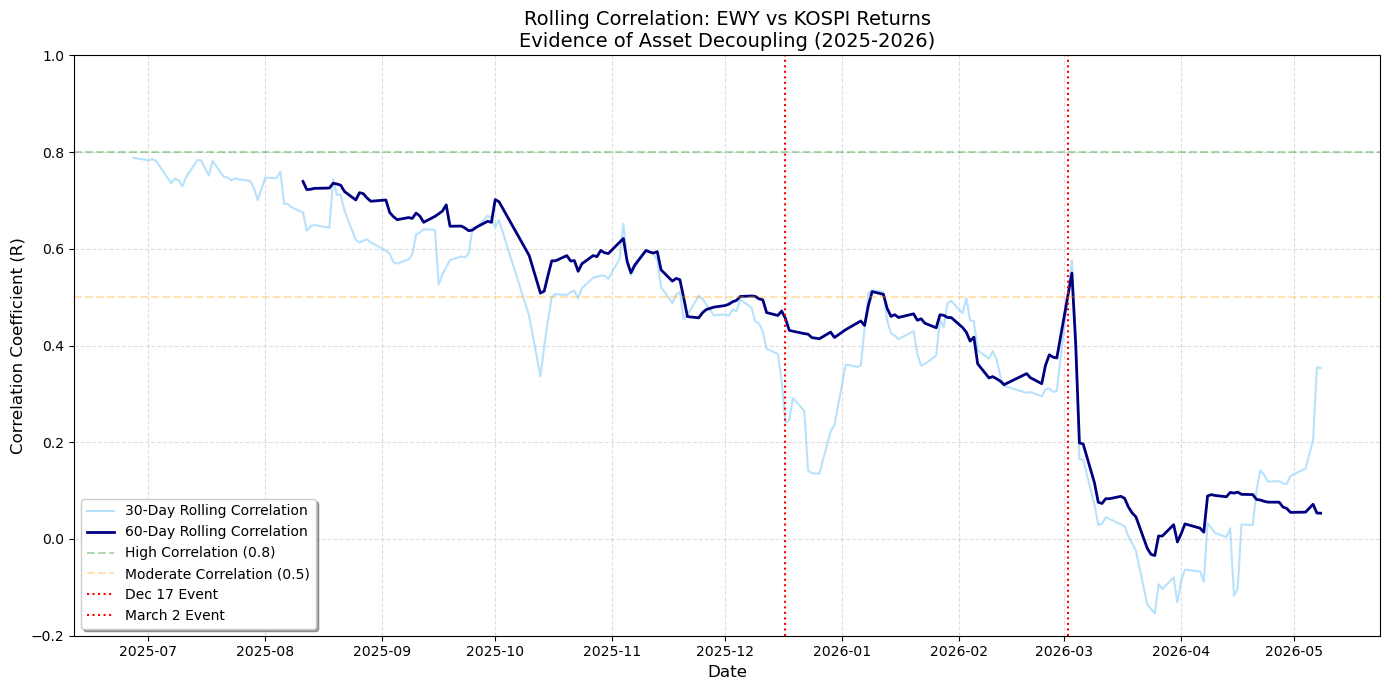

In [106]:
corr_df = pd.concat([EWY_data['Returns'], KOSPI_data['Returns']], axis=1).dropna()
corr_df.columns = ['EWY_Returns', 'KOSPI_Returns']

window_short = 30
window_long = 60

corr_df['Rolling_30'] = corr_df['EWY_Returns'].rolling(window=window_short).corr(corr_df['KOSPI_Returns'])
corr_df['Rolling_60'] = corr_df['EWY_Returns'].rolling(window=window_long).corr(corr_df['KOSPI_Returns'])

plt.figure(figsize=(14, 7))

# Plot the correlations
plt.plot(corr_df.index, corr_df['Rolling_30'], label=f'{window_short}-Day Rolling Correlation', color='lightskyblue', alpha=0.6)
plt.plot(corr_df.index, corr_df['Rolling_60'], label=f'{window_long}-Day Rolling Correlation', color='navy', linewidth=2)

# Add a horizontal line at 0.5 (Moderate correlation) and 0.8 (High correlation)
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3, label='High Correlation (0.8)')
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.3, label='Moderate Correlation (0.5)')

# Add markers for your key events
plt.axvline(pd.to_datetime('2025-12-17'), color='red', linestyle=':', label='Dec 17 Event')
plt.axvline(pd.to_datetime('2026-03-02'), color='red', linestyle=':', label='March 2 Event')

# Formatting
plt.title('Rolling Correlation: EWY vs KOSPI Returns\nEvidence of Asset Decoupling (2025-2026)', fontsize=14)
plt.ylabel('Correlation Coefficient (R)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylim(-0.2, 1.0) # Correlation ranges from -1 to 1, but we expect positive
plt.legend(loc='lower left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [515]:
# VIX Filter
def backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold = 0.01, vix_threshold=20):
    """
    EWY_data, KOSPI_data, KRW_data: DFs with 'Returns' and DatetimeIndex.
    Logic: Calculate WTD spread on Wed EOD, trade Thu/Fri.
    """
    # 1. Align and combine data
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI': KOSPI_data['Returns'],
        'KRW': KRW_data['Returns']
    }).dropna()
    
    # 2. Adjust KOSPI to USD terms (to match EWY)
    df['KOSPI_USD'] = (1 + df['KOSPI']) * (1 + df['KRW']) - 1
    df['VIX'] = VIX_data['Adj Close'].reindex(df.index).ffill()
    
    # 3. Identify Day of Week (0=Mon, 2=Wed, 3=Thu, 4=Fri)
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year

    # 4. Calculate Week-to-Date (WTD) Returns
    # We group by year/week and calculate cumulative return
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    
    # 5. Calculate the Midweek Spread (Wednesday EOD)
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']
    
    # 6. Generate Trade Signals
    # We look at the spread on Wednesday (Day 2) to trade on Thursday (Day 3)
    df['Signal'] = 0
    
    # Based on threshold: e.g., if spread > 1%, bet on convergence    
    # Extract Wednesday values and shift them to Thursday/Friday
    wed_signals = df[df['Day'] == 2][['Spread_WTD', 'VIX']]
    
    
    for idx, row in wed_signals.iterrows():
        # Target the following Thursday and Friday
        mask = (df['Week_ID'] == df.loc[idx, 'Week_ID']) & \
               (df['Year_ID'] == df.loc[idx, 'Year_ID']) & \
               (df['Day'] >= 3)

        # VIX Filter
        if row['VIX'] > vix_threshold:
            if row['Spread_WTD'] > threshold:
                df.loc[mask, 'Signal'] = -1  # EWY too high -> Short EWY / Long KOSPI
            elif row['Spread_WTD'] < -threshold:
                df.loc[mask, 'Signal'] = 1   # EWY too low -> Long EWY / Short KOSPI
        else:
            # If VIX is high, we stay out (Signal remains 0)
            pass

    # 7. Calculate Strategy Returns
    # Return = Signal * (Long Leg Return - Short Leg Return)
    # If Signal is 1 (Long EWY), profit = EWY - KOSPI_USD
    # If Signal is -1 (Short EWY), profit = KOSPI_USD - EWY
    df['Strategy_Ret'] = df['Signal'] * (df['EWY'] - df['KOSPI_USD'])
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()

    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

# Usage
results_df = backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, 0.01)

In [529]:
# Long only vix filter
def backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, VIX_data, threshold=0.01, vix_threshold=25):
    """
    Long-Only Relative Value:
    If EWY lagged KOSPI by > threshold on Wed: Hold EWY Thu/Fri.
    If KOSPI lagged EWY by > threshold on Wed: Hold KOSPI Thu/Fri.
    Otherwise: No trade (or you could default to a 50/50 split).
    """
    # 1. Align and combine data
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI': KOSPI_data['Returns'],
        'KRW': KRW_data['Returns']
    }).dropna()
    
    # Map VIX and fill gaps
    df['KOSPI_USD'] = (1 + df['KOSPI']) * (1 + df['KRW']) - 1
    df['VIX'] = VIX_data['Adj Close'].reindex(df.index).ffill()
    
    # 3. Identify Day/Week/Year
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year

    # 4. Calculate WTD Returns
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    
    # 5. Calculate Spread (EWY - KOSPI)
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']
    
    # 6. Generate Trade Signals
    # Signal 1: Long EWY
    # Signal -1: Long KOSPI
    df['Signal'] = 0
    
    wed_data = df[df['Day'] == 2][['Spread_WTD', 'VIX']]
    
    for idx, row in wed_data.iterrows():
        mask = (df['Week_ID'] == df.loc[idx, 'Week_ID']) & \
               (df['Year_ID'] == df.loc[idx, 'Year_ID']) & \
               (df['Day'] >= 3)
        
        if row['VIX'] < vix_threshold:
            if row['Spread_WTD'] < -threshold:
                # EWY has lagged significantly -> Long EWY
                df.loc[mask, 'Signal'] = 1
            elif row['Spread_WTD'] > threshold:
                # KOSPI has lagged significantly -> Long KOSPI
                df.loc[mask, 'Signal'] = -1

    # 7. Calculate Strategy Returns
    # If Signal is 1, we get EWY returns. 
    # If Signal is -1, we get KOSPI_USD returns.
    # We use np.select for clean conditional assignment
    import numpy as np
    conditions = [
        (df['Signal'] == 1),
        (df['Signal'] == -1)
    ]
    choices = [
        df['EWY'],
        df['KOSPI_USD']
    ]
    df['Strategy_Ret'] = np.select(conditions, choices, default=0)
    
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()
    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

results_df = backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, VIX_data, 0.01)

In [537]:
# Long only 
def backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, threshold=0.01):
    """
    Long-Only Rotation Strategy:
    Logic: On Wednesday EOD, identify if one asset significantly lagged the other.
    Trade: Hold only the laggard on Thursday and Friday.
    """
    # 1. Align and combine data
    df = pd.DataFrame({
        'EWY': EWY_data['Returns'],
        'KOSPI': KOSPI_data['Returns'],
        'KRW': KRW_data['Returns']
    }).dropna()
    
    # 2. Adjust KOSPI to USD terms (to match EWY)
    df['KOSPI_USD'] = (1 + df['KOSPI']) * (1 + df['KRW']) - 1
    
    # 3. Identify Day of Week (0=Mon, 2=Wed, 3=Thu, 4=Fri)
    df['Day'] = df.index.dayofweek
    df['Week_ID'] = df.index.isocalendar().week
    df['Year_ID'] = df.index.isocalendar().year

    # 4. Calculate Week-to-Date (WTD) Returns
    df['EWY_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['EWY'].transform(lambda x: (1 + x).cumprod() - 1)
    df['KOSPI_WTD'] = df.groupby(['Year_ID', 'Week_ID'])['KOSPI_USD'].transform(lambda x: (1 + x).cumprod() - 1)
    
    # 5. Calculate the Midweek Spread (EWY - KOSPI)
    df['Spread_WTD'] = df['EWY_WTD'] - df['KOSPI_WTD']
    
    # 6. Generate Trade Signals
    # Signal 1: EWY lagged -> Long EWY
    # Signal -1: KOSPI lagged -> Long KOSPI
    df['Signal'] = 0
    
    wed_signals = df[df['Day'] == 2][['Spread_WTD']]
    
    for idx, row in wed_signals.iterrows():
        mask = (df['Week_ID'] == df.loc[idx, 'Week_ID']) & \
               (df['Year_ID'] == df.loc[idx, 'Year_ID']) & \
               (df['Day'] >= 3)
        
        if row['Spread_WTD'] < -threshold:
            # EWY is the laggard
            df.loc[mask, 'Signal'] = 1
        elif row['Spread_WTD'] > threshold:
            # KOSPI is the laggard
            df.loc[mask, 'Signal'] = -1

    # 7. Calculate Strategy Returns
    # Switch between EWY and KOSPI based on signal; stay in cash (0) if no signal
    conditions = [
        (df['Signal'] == 1),
        (df['Signal'] == -1)
    ]
    choices = [
        df['EWY'],
        df['KOSPI_USD']
    ]
    
    df['Strategy_Ret'] = np.select(conditions, choices, default=0)
    
    # 8. Cumulative Performance
    df['Cumu_Strategy_Ret'] = (1 + df['Strategy_Ret']).cumprod()
    df['Buy_and_Hold_KOSPI'] = (1 + df['KOSPI_USD']).cumprod()
    df['Buy_and_Hold_EWY'] = (1 + df['EWY']).cumprod()
    
    return df

results_df = backtest_midweek_convergence(EWY_data, KOSPI_data, KRW_data, 0.01)

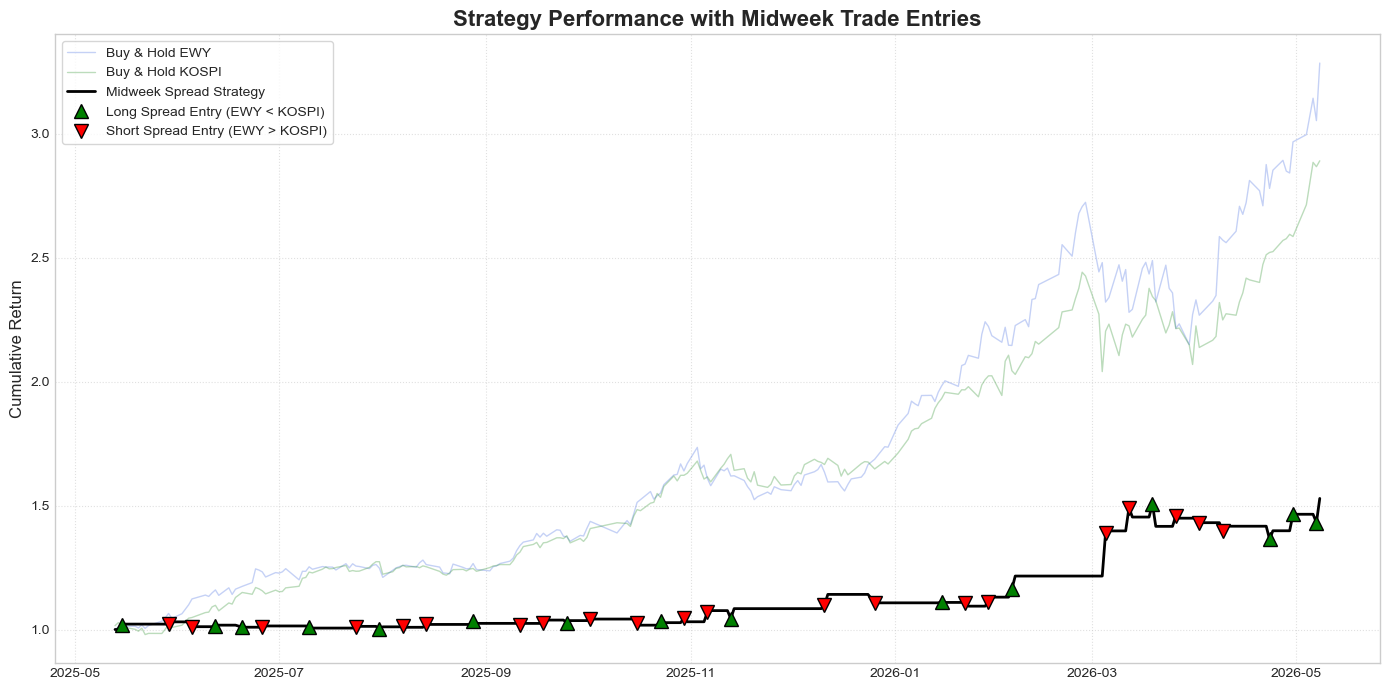

In [431]:
import matplotlib.pyplot as plt

def plot_with_trade_markers(df):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(14, 7))

    # 1. Plot Cumulative Lines
    ax.plot(df.index, df['Buy_and_Hold_EWY'], label='Buy & Hold EWY', color='royalblue', alpha=0.3, lw=1)
    ax.plot(df.index, df['Buy_and_Hold_KOSPI'], label='Buy & Hold KOSPI', color='forestgreen', alpha=0.3, lw=1)
    ax.plot(df.index, df['Cumu_Strategy_Ret'], label='Midweek Spread Strategy', color='black', lw=2)

    # 2. Identify Entry Points
    # We define an entry as the first day (Thursday) the signal becomes non-zero for that week
    # This avoids plotting markers on both Thursday AND Friday for the same trade.
    df['Entry'] = (df['Signal'] != 0) & (df['Signal'].shift(1) == 0)
    
    long_entries = df[df['Entry'] & (df['Signal'] == 1)]
    short_entries = df[df['Entry'] & (df['Signal'] == -1)]

    # 3. Add Markers
    # 'g^' is green triangle up, 'rv' is red triangle down
    ax.plot(long_entries.index, long_entries['Cumu_Strategy_Ret'], 'g^', 
            markersize=10, label='Long Spread Entry (EWY < KOSPI)', markeredgecolor='k')
    
    ax.plot(short_entries.index, short_entries['Cumu_Strategy_Ret'], 'rv', 
            markersize=10, label='Short Spread Entry (EWY > KOSPI)', markeredgecolor='k')

    # 4. Formatting
    ax.set_title('Strategy Performance with Midweek Trade Entries', fontsize=16, fontweight='bold')
    ax.set_ylabel('Cumulative Return', fontsize=12)
    ax.legend(loc='best', frameon=True)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Execute
plot_with_trade_markers(results_df)

C:\Users\Raymon\AppData\Local\Temp\ipykernel_2356\4106111513.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.014399049828290877' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mon_wed.index, 'MonWed_Returns_EWY'] = cum_ret_ewy
C:\Users\Raymon\AppData\Local\Temp\ipykernel_2356\4106111513.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.020459149981939095' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mon_wed.index, 'MonWed_Returns_KOSPI'] = cum_ret_kospi
C:\Users\Raymon\AppData\Local\Temp\ipykernel_2356\4106111513.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.006060100153648218' has dtype incompatible with int64, pleas

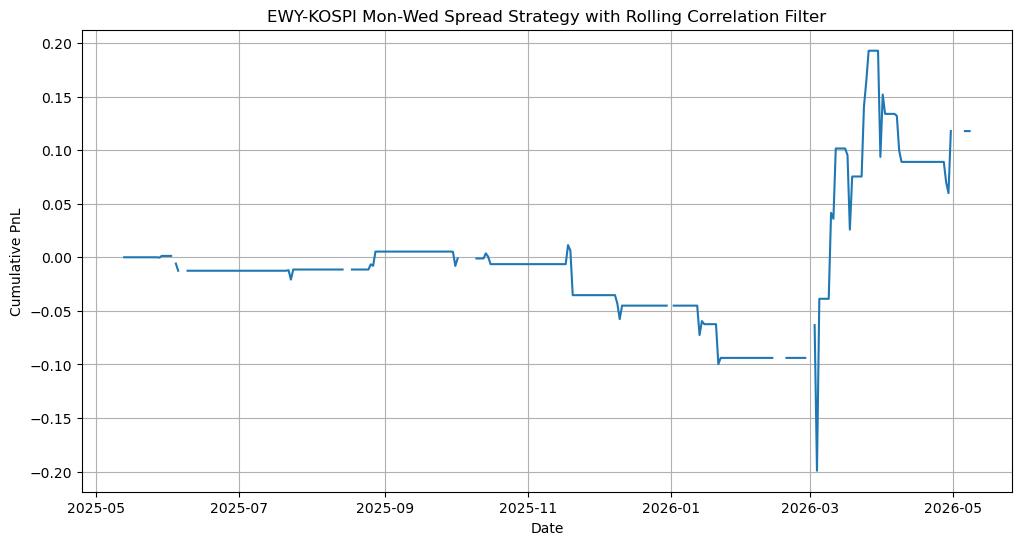

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure index is datetime
EWY_data.index = pd.to_datetime(EWY_data.index)
KOSPI_data.index = pd.to_datetime(KOSPI_data.index)

# Merge on index
data = EWY_data.join(KOSPI_data, lsuffix='_EWY', rsuffix='_KOSPI')

# Compute week number and day of week
data['Week'] = data.index.isocalendar().week
data['DayOfWeek'] = data.index.dayofweek  # Monday=0, ..., Friday=4

# Initialize columns
data['MonWed_Returns_EWY'] = 0
data['MonWed_Returns_KOSPI'] = 0
data['Spread_MonWed'] = 0
data['Signal_EWY'] = 0
data['Signal_KOSPI'] = 0

# Compute rolling weekly correlation (using past 4 weeks of Mon-Wed returns)
rolling_corr_weeks = 4
weekly_returns = []

for week, group in data.groupby('Week'):
    mon_wed = group[group['DayOfWeek'] <= 2]
    if len(mon_wed) == 0:
        continue
    
    # Cumulative Mon-Wed return
    cum_ret_ewy = (mon_wed['Returns_EWY'] + 1).prod() - 1
    cum_ret_kospi = (mon_wed['Returns_KOSPI'] + 1).prod() - 1
    spread = cum_ret_ewy - cum_ret_kospi
    
    data.loc[mon_wed.index, 'MonWed_Returns_EWY'] = cum_ret_ewy
    data.loc[mon_wed.index, 'MonWed_Returns_KOSPI'] = cum_ret_kospi
    data.loc[mon_wed.index, 'Spread_MonWed'] = spread
    
    # Store for correlation calculation
    weekly_returns.append((cum_ret_ewy, cum_ret_kospi))
    
    # Compute rolling correlation if we have enough history
    if len(weekly_returns) > rolling_corr_weeks:
        corr_df = pd.DataFrame(weekly_returns[-rolling_corr_weeks:], columns=['EWY','KOSPI'])
        rolling_corr = corr_df['EWY'].corr(corr_df['KOSPI'])
    else:
        rolling_corr = 1  # assume high correlation initially
    
    # Apply threshold filter for spread-based signal
    threshold = 0.015
    if abs(rolling_corr) >= 0.7:
        if spread > threshold:
            data.loc[mon_wed.index, 'Signal_EWY'] = -1
            data.loc[mon_wed.index, 'Signal_KOSPI'] = 1
        elif spread < -threshold:
            data.loc[mon_wed.index, 'Signal_EWY'] = 1
            data.loc[mon_wed.index, 'Signal_KOSPI'] = -1
    else:
        # Weak correlation, skip trading
        data.loc[mon_wed.index, 'Signal_EWY'] = 0
        data.loc[mon_wed.index, 'Signal_KOSPI'] = 0

# Compute strategy PnL (enter next day)
data['PnL'] = data['Signal_EWY'].shift(1) * data['Returns_EWY'] + \
              data['Signal_KOSPI'].shift(1) * data['Returns_KOSPI']

# Cumulative PnL
data['CumulativePnL'] = data['PnL'].cumsum()

# Plot cumulative PnL
plt.figure(figsize=(12,6))
plt.plot(data.index, data['CumulativePnL'])
plt.title('EWY-KOSPI Mon-Wed Spread Strategy with Rolling Correlation Filter')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.grid(True)
plt.show()

C:\Users\Raymon\AppData\Local\Temp\ipykernel_2356\1425078640.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.014399049828290877' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mon_wed.index, 'MonWed_Returns_EWY'] = cum_ret_ewy
C:\Users\Raymon\AppData\Local\Temp\ipykernel_2356\1425078640.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.020459149981939095' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[mon_wed.index, 'MonWed_Returns_KOSPI'] = cum_ret_kospi
C:\Users\Raymon\AppData\Local\Temp\ipykernel_2356\1425078640.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.006060100153648218' has dtype incompatible with int64, pleas

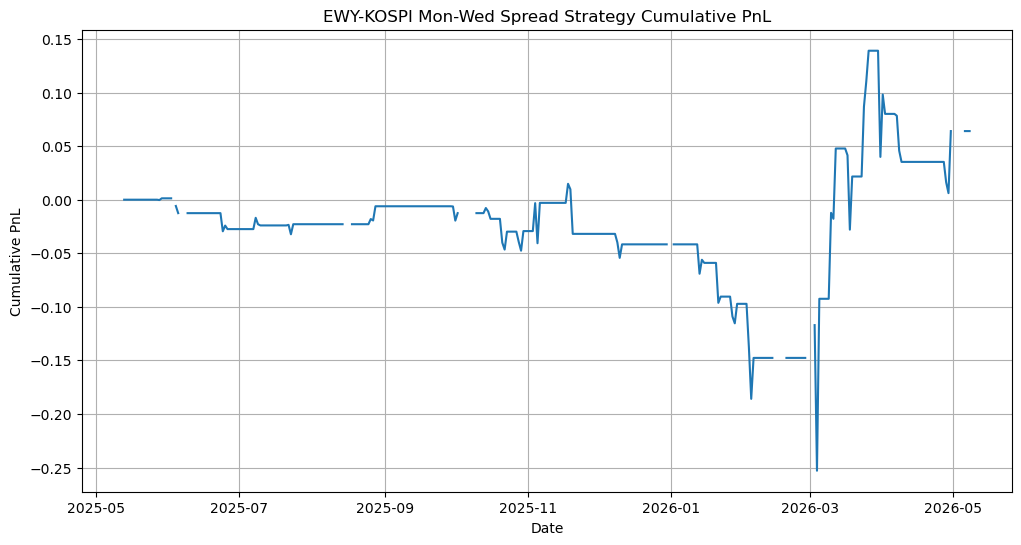

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure index is datetime
EWY_data.index = pd.to_datetime(EWY_data.index)
KOSPI_data.index = pd.to_datetime(KOSPI_data.index)

# Merge on index
data = EWY_data.join(KOSPI_data, lsuffix='_EWY', rsuffix='_KOSPI')

# Compute week number
data['Week'] = data.index.isocalendar().week
data['DayOfWeek'] = data.index.dayofweek  # Monday=0, Tuesday=1, ...

# Initialize columns
data['MonWed_Returns_EWY'] = 0
data['MonWed_Returns_KOSPI'] = 0
data['Spread_MonWed'] = 0
data['Signal_EWY'] = 0
data['Signal_KOSPI'] = 0

# Calculate Monday-Wednesday returns and spread
for week, group in data.groupby('Week'):
    # Take Mon-Wed only
    mon_wed = group[group['DayOfWeek'] <= 2]
    if len(mon_wed) == 0:
        continue
    
    # Cumulative return from Monday to Wednesday
    cum_ret_ewy = (mon_wed['Returns_EWY'] + 1).prod() - 1
    cum_ret_kospi = (mon_wed['Returns_KOSPI'] + 1).prod() - 1
    
    # Spread
    spread = cum_ret_ewy - cum_ret_kospi
    
    # Store
    data.loc[mon_wed.index, 'MonWed_Returns_EWY'] = cum_ret_ewy
    data.loc[mon_wed.index, 'MonWed_Returns_KOSPI'] = cum_ret_kospi
    data.loc[mon_wed.index, 'Spread_MonWed'] = spread
    
    # Generate signals based on spread threshold
    threshold = 0.015  
    if spread > threshold:
        data.loc[mon_wed.index, 'Signal_EWY'] = -1
        data.loc[mon_wed.index, 'Signal_KOSPI'] = 1
    elif spread < -threshold:
        data.loc[mon_wed.index, 'Signal_EWY'] = 1
        data.loc[mon_wed.index, 'Signal_KOSPI'] = -1

# Compute strategy PnL (enter next day)
data['PnL'] = data['Signal_EWY'].shift(1) * data['Returns_EWY'] + \
              data['Signal_KOSPI'].shift(1) * data['Returns_KOSPI']

# Cumulative PnL
data['CumulativePnL'] = data['PnL'].cumsum()

# Plot cumulative PnL
plt.figure(figsize=(12,6))
plt.plot(data.index, data['CumulativePnL'])
plt.title('EWY-KOSPI Mon-Wed Spread Strategy Cumulative PnL')
plt.xlabel('Date')
plt.ylabel('Cumulative PnL')
plt.grid(True)
plt.show()

#### JUnk

In [ ]:
import scipy.stats as stats

# 1. Align data and remove the first row (NaN from pct_change)
combined_df = pd.concat([SMH_data['Returns'], EWY_data['Returns']], axis=1).dropna()
combined_df.columns = ['SMH', 'EWY']

# 2. Perform Linear Regression (y = EWY, x = KOSPI)
slope, intercept, r_value, p_value, std_err = stats.linregress(combined_df['SMH'], combined_df['EWY'])

# 3. Calculate R-squared
r_squared = r_value**2

print(f"Correlation (R): {r_value:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Beta (Slope): {slope:.4f}")
print(f"Alpha (Intercept): {intercept:.4f}")

# 4. Plot the Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(combined_df['SMH'], combined_df['EWY'], alpha=0.5, label='Actual Data')
plt.plot(combined_df['SMH'], intercept + slope * combined_df['SMH'], color='red', label='Regression Line')

plt.title(f'Regression: EWY vs SMH Returns (R² = {r_squared:.3f})')
plt.xlabel('SMH Daily Returns')
plt.ylabel('EWY Daily Returns')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
EWY_l50 = EWY_data.iloc[-50:,:].copy()
KOSPI_l50 = KOSPI_data.iloc[-50:,:].copy()
KRW_l50 = KRW_data.iloc[-50:,:].copy()


### Adding KRW
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Align data and handle NaNs
combined_df = pd.concat([KOSPI_l50['Returns'], EWY_l50['Returns'], KRW_l50['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY', 'KRW']

# 2. Define your variables
# y is what we want to explain (EWY)
# X contains our predictors (KOSPI and KRW)
y = combined_df['EWY']
X = combined_df[['KOSPI', 'KRW']]

# 3. Add a constant (Alpha/Intercept)
# Statsmodels doesn't include an intercept by default
X = sm.add_constant(X)

# 4. Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()

# 5. Output Results
print(model.summary())

# 6. Visualization: Actual vs. Predicted
# (Since we have 2 predictors, we can't do a simple 2D line plot easily. 
# A common way to show fit is 'Actual vs Predicted')
combined_df['Predicted_EWY'] = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(combined_df['EWY'], combined_df['Predicted_EWY'], alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--') # 45-degree line

plt.title(f'Multiple Regression: EWY vs (KOSPI + KRW)\nR-squared: {model.rsquared:.4f}')
plt.xlabel('Actual EWY Returns')
plt.ylabel('Predicted EWY Returns')
plt.grid(True)
plt.show()

Correlation (R): 0.9953
R-squared: 0.9907
Beta (Slope): 1.1533
Alpha (Intercept): -0.1509


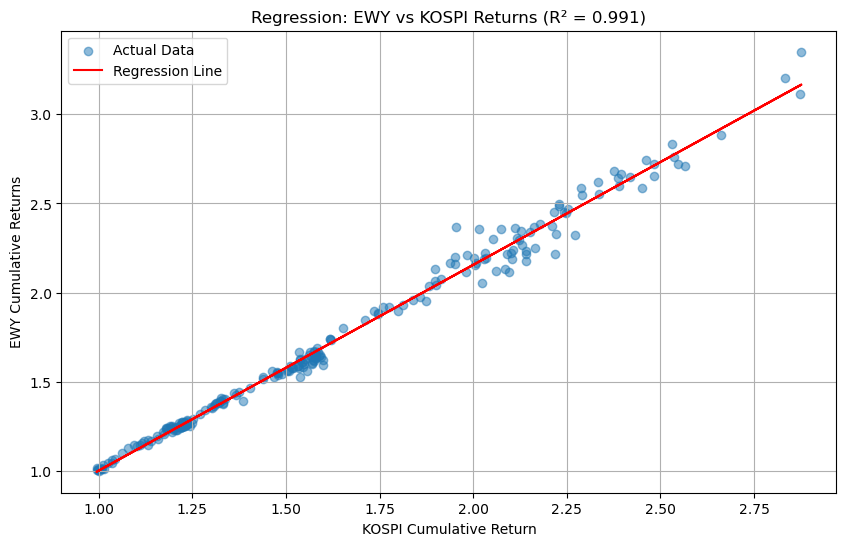

In [221]:
# spurious correlation
import scipy.stats as stats

# 1. Align data and remove the first row (NaN from pct_change)
combined_df = pd.concat([KOSPI_data['Cumulative Returns'], EWY_data['Cumulative Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY']

# 2. Perform Linear Regression (y = EWY, x = KOSPI)
slope, intercept, r_value, p_value, std_err = stats.linregress(combined_df['KOSPI'], combined_df['EWY'])

# 3. Calculate R-squared
r_squared = r_value**2

print(f"Correlation (R): {r_value:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Beta (Slope): {slope:.4f}")
print(f"Alpha (Intercept): {intercept:.4f}")

# 4. Plot the Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(combined_df['KOSPI'], combined_df['EWY'], alpha=0.5, label='Actual Data')
plt.plot(combined_df['KOSPI'], intercept + slope * combined_df['KOSPI'], color='red', label='Regression Line')

plt.title(f'Regression: EWY vs KOSPI Returns (R² = {r_squared:.3f})')
plt.xlabel('KOSPI Cumulative Return')
plt.ylabel('EWY Cumulative Returns')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
EWY_l50 = EWY_data.iloc[-50:,:]
KOSPI_l50 = KOSPI_data.iloc[-50:,:]

# 1. Align data and remove the first row (NaN from pct_change)
combined_df = pd.concat([EWY_l50['Returns'], KOSPI_l50['Returns']], axis=1).dropna()
combined_df.columns = ['KOSPI', 'EWY']

# 2. Perform Linear Regression (y = EWY, x = KOSPI)
slope, intercept, r_value, p_value, std_err = stats.linregress(combined_df['KOSPI'], combined_df['EWY'])

# 3. Calculate R-squared
r_squared = r_value**2

print(f"Correlation (R): {r_value:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Beta (Slope): {slope:.4f}")
print(f"Alpha (Intercept): {intercept:.4f}")

# 4. Plot the Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(combined_df['KOSPI'], combined_df['EWY'], alpha=0.5, label='Actual Data')
plt.plot(combined_df['KOSPI'], intercept + slope * combined_df['KOSPI'], color='red', label='Regression Line')

plt.title(f'Regression: EWY vs KOSPI Returns (R² = {r_squared:.3f})')
plt.xlabel('KOSPI Daily Returns')
plt.ylabel('EWY Daily Returns')
plt.legend()
plt.grid(True)
plt.show()